# Modeling #

Given that the goal of this model is to make a numerical prediction, I believe using a regression model would be best.

In this section, we'll be using different models to try to identify which one is the best fit. We'll be using the following models:
- Linear Regression
- Ridge Regression
- Gradient Boosted Regression
- Random Forest

## Imports
#### Packages

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import re
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
# Linear Regression 
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
#Ridge Regression imports
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Random Forest imports
from sklearn.ensemble import RandomForestRegressor


Matplotlib is building the font cache; this may take a moment.


#### Loading Data

In [2]:
modeling_data_dir = ('../data/processed/modeling/')

X_train = pd.read_csv(modeling_data_dir + 'X_train.csv', index_col='row_id')
X_test = pd.read_csv(modeling_data_dir + 'X_test.csv', index_col='row_id')
y_train = pd.read_csv(modeling_data_dir + 'y_train.csv', index_col='row_id')['salary_midpoint']
y_test = pd.read_csv(modeling_data_dir + 'y_test.csv', index_col='row_id')['salary_midpoint']

#### Modeling decisions

- **Starting with Linear Regression:**  Since the goal is to predict a salary, a numeric number, linear regression seemed like a good starting point. It is a simple model that makes it easier to see how each feature relates to the prediction. It assumes that the features have a linear relationship with salary, but salary itself does not need to follow a normal distribution.
- **Removing two category columns:** Education and experience each have a separate column for every category. Since the model also includes a starting value called an intercept, keeping all of these columns would give it repeated information. I removed `education_bachelors` and `experience_Entry` so the model can use Bachelor's and Entry as the comparison groups for the other categories.
- **Keeping the current feature scales:** I did not add a scaling step because ordinary Linear Regression does not penalize large coefficients, and rescaling the features should not change its predictions. This also lets me read the coefficients in salary dollars for a one-unit change in a feature. The years feature is already scaled from 0 to 1, so its coefficient describes the predicted difference between the lowest and highest experience requirements in that scale.
- **Checking the model with five folds:** I split the training data into five groups. The model trains on four groups and is checked on the remaining group, repeating this until each group has been used for checking. This helps me see whether the model performs similarly across different parts of the data. I used a fixed random seed so I can repeat the same splits.
- **Comparing prediction errors:** I used mean absolute error (MAE) as the main score because it tells me how far off the predictions are on average in dollars. I also included RMSE, which puts more weight on large mistakes, and R², which shows how much of the variation in salary the model explains.
- **Comparing against a simple guess:** I compared the model with one that predicts the average training salary for every job. This helps me check whether using the job features improves predictions over just using the average.


#### Preparing the data

In [3]:
# Confirm that every feature row matches the correct target row.
# Matching indexes prevent salaries from being paired with the wrong job postings.
train_rows_match = X_train.index.equals(y_train.index)
test_rows_match = X_test.index.equals(y_test.index)

if not train_rows_match or not test_rows_match:
    raise ValueError('Feature and target row IDs are not aligned')

In [4]:
# Models in this notebook require complete numeric data.
# Check both features and targets before fitting any model.
training_features_have_missing_values = X_train.isna().any().any()
training_target_has_missing_values = y_train.isna().any()

if training_features_have_missing_values or training_target_has_missing_values:
    raise ValueError('Training data contains missing values')

In [5]:
# Use Bachelor's degree and Entry level as reference categories.
# Dropping one indicator from each category avoids perfect multicollinearity.
reference_columns = [
    'education_bachelors',
    'experience_Entry',
]

X_train_linear = X_train.drop(columns=reference_columns)
X_test_linear = X_test.drop(columns=reference_columns)

#### Cross validation and model fitting

In [6]:
# Create an ordinary least-squares regression model.
linear_model = LinearRegression()

# KFold defines how the training data will be divided for cross validation.
# shuffle=True mixes the row order before creating the five folds.
# random_state makes those folds reproducible.
linear_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [7]:
# Train and validate the model five times.
# Scikit-learn returns negative MAE because it treats larger scores as better.
# Multiplying by -1 converts the scores back into positive dollar errors.
linear_cv_mae = -cross_val_score(
    estimator=linear_model,
    X=X_train_linear,
    y=y_train,
    cv=linear_cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

print(f'Mean validation MAE: ${linear_cv_mae.mean():,.0f}')
print(f'Validation MAE standard deviation: ${linear_cv_mae.std():,.0f}')

Mean validation MAE: $9,757
Validation MAE standard deviation: $159


In [8]:
# Fit one final linear model using all available training rows.
# This fitted model will make predictions for the untouched test rows.
linear_model.fit(X_train_linear, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


The cross-validation mean estimates the model's typical error on unseen training-like rows. Its standard deviation shows how much that estimate changed among folds. A small standard deviation relative to the mean suggests that performance is reasonably stable across these splits.

#### Test-set predictions and metrics

In [9]:
# Use the fitted linear model to predict salary midpoints for the test set.
linear_predictions = linear_model.predict(X_test_linear)

In [10]:
# Build a simple comparison model that predicts the training-set mean.
# A useful model should perform substantially better than the baseline.
linear_baseline = DummyRegressor(strategy='mean')
linear_baseline.fit(X_train_linear, y_train)
linear_baseline_predictions = linear_baseline.predict(X_test_linear)

In [11]:
# Comparing the linear model to the baseline model on the test set with this
def regression_metrics(actual, predicted):
    """Return three common regression metrics for a set of predictions."""
    # MAE is the average absolute prediction error in salary dollars.
    mae = mean_absolute_error(actual, predicted)

    # RMSE gives additional weight to unusually large prediction errors.
    rmse = mean_squared_error(actual, predicted) ** 0.5

    # R squared measures the share of target variation explained by the model.
    r_squared = r2_score(actual, predicted)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r_squared,
    }

In [12]:
# Put baseline and linear-model results into one table for comparison.
linear_results = pd.DataFrame({
    'Mean baseline': regression_metrics(y_test, linear_baseline_predictions),
    'Linear regression': regression_metrics(y_test, linear_predictions),
}).T

linear_results

,MAE,RMSE,R²
Mean baseline,40566.999697,48596.955725,-0.001553
Linear regression,9497.197050,12127.472434,0.937627


#### Reading the coefficients

Each coefficient is the predicted salary-midpoint change associated with that feature when all other included features are held fixed. For example, `experience_Mid` compares Mid with the omitted Entry category. Skill coefficients compare postings containing that skill with otherwise identical postings without it. Because predictors can be correlated, these are adjusted associations rather than causal effects.

In [13]:
# Match every fitted coefficient with its feature name.
linear_coefficients = pd.Series(
    data=linear_model.coef_,
    index=X_train_linear.columns,
    name='coefficient',
)

# Sort by absolute size so the strongest model associations appear first.
linear_coefficients = linear_coefficients.sort_values(
    key=abs,
    ascending=False,
)

print(f'Intercept: ${linear_model.intercept_:,.0f}')
linear_coefficients.to_frame()

Intercept: $104,571


,coefficient
experience_Senior,125947.197301
experience_Mid,45375.451093
years_experience_normalized,4881.654763
skill_supervised_learning,2185.623521
skill_ci_cd,1267.381100
skill_lightgbm,-1050.969533
skill_regression,-938.482013
education_masters,-898.850994
skill_scikit_learn,-857.416964
skill_pytorch,-825.210930


#### Diagnostic plots

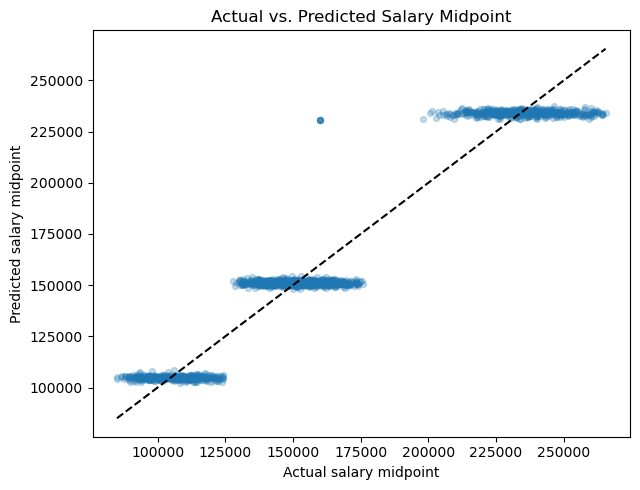

In [14]:
# Plot actual salaries against model predictions.
plt.figure(figsize=(6.5, 5))
plt.scatter(y_test, linear_predictions, alpha=0.25, s=18)

# Create a diagonal line showing where perfect predictions would fall.
linear_limits = [
    min(y_test.min(), linear_predictions.min()),
    max(y_test.max(), linear_predictions.max()),
]
plt.plot(linear_limits, linear_limits, '--', color='black')

plt.title('Actual vs. Predicted Salary Midpoint')
plt.xlabel('Actual salary midpoint')
plt.ylabel('Predicted salary midpoint')
plt.tight_layout()
plt.show()

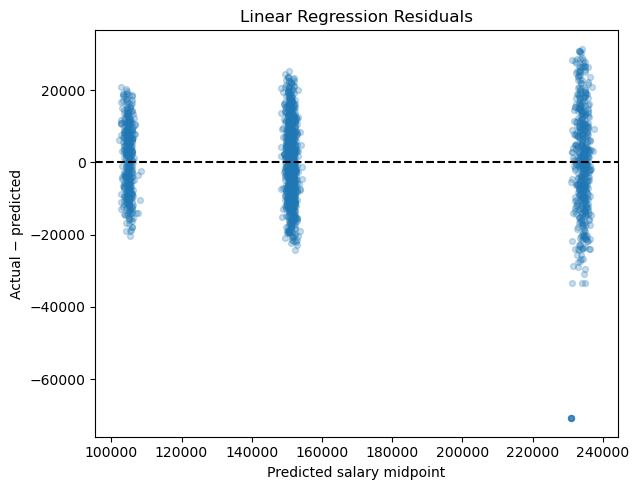

In [15]:
# A residual is the actual value minus the predicted value.
linear_residuals = y_test - linear_predictions

plt.figure(figsize=(6.5, 5))
plt.scatter(linear_predictions, linear_residuals, alpha=0.25, s=18)

# The horizontal line marks zero error.
plt.axhline(0, linestyle='--', color='black')
plt.title('Linear Regression Residuals')
plt.xlabel('Predicted salary midpoint')
plt.ylabel('Actual − predicted')
plt.tight_layout()
plt.show()

The diagonal in the first plot represents perfect predictions. Points above it were underpredicted, while points below it were overpredicted. In the residual plot, a strong curve would suggest that a straight-line relationship is missing structure. A widening spread would suggest that error variance changes across predicted salary levels.

For the current split, Linear Regression produced a cross-validation MAE of approximately **$9,757** with a fold-to-fold standard deviation of approximately **$159**. Its test MAE was approximately **$9,497**, test RMSE was approximately **$12,127**, and test R^2 was approximately **0.938**. The mean baseline's test MAE was approximately **$40,567**. Experience-level indicators had the largest coefficients, which agrees with the earlier exploratory analysis.

### Model 2: Ridge Regression

#### Modeling decisions

- **Trying Ridge Regression:** I chose Ridge as the next model because it works like Linear Regression but adds a penalty that keeps the coefficients from becoming too large. This can help when features contain similar information, such as years of experience and experience level. I wanted to see whether this extra step would improve salary predictions.
- **Putting features on a similar scale:** Since Ridge penalizes large coefficients, the scale of each feature matters. I used `StandardScaler` to put the features on a similar scale before fitting the model. I kept the scaler and model together in a pipeline so the scaling is learned only from the training part of each split.
- **Trying different penalty strengths:** The `alpha` setting controls how strong the penalty is. Instead of picking one value myself, I tested values from 0.001 to 10,000 in steps that cover a wide range. Small values keep the model close to ordinary Linear Regression, while large values shrink the coefficients more.
- **Checking the model with five folds:** I used five groups of training data to compare the different `alpha` values. Each group takes a turn being used to check a model trained on the other four groups. I shuffled the rows with `random_state=42` so the same splits can be used again.
- **Choosing the model using MAE:** I used mean absolute error (MAE) to choose the best `alpha` because it gives an average prediction error in salary dollars. It is easy to understand and gives less weight to unusually large mistakes than squared-error scores do.
- **Saving the test data for the end:** I used only `X_train` and `y_train` to choose `alpha`. Once that choice was made, I used `X_test` and `y_test` for the final check to see how well the model predicts salaries for rows it had not trained on.


#### Confirming the Ridge input data

In [16]:
# Ridge uses the complete indicator sets because its penalty can handle
# their overlap. Confirm again that features and targets remain aligned.
train_rows_match = X_train.index.equals(y_train.index)
test_rows_match = X_test.index.equals(y_test.index)

if not train_rows_match or not test_rows_match:
    raise ValueError('Feature and target row IDs are not aligned')

In [17]:
# Check every Ridge feature and target for missing values.
training_features_have_missing_values = X_train.isna().any().any()
training_target_has_missing_values = y_train.isna().any()

if training_features_have_missing_values or training_target_has_missing_values:
    raise ValueError('Training data contains missing values')

#### Ridge pipeline and parameter search

In [18]:
# A Pipeline guarantees that scaling happens before Ridge regression.
# During cross validation, StandardScaler learns only from each training fold.
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge()),
])

In [19]:
# Generate 50 possible alpha values on a logarithmic scale.
# Small alpha values apply little regularization; large values apply more.
ridge_parameters = {
    'ridge__alpha': np.logspace(-3, 4, 50),
}

# Use the same reproducible five-fold setup used for Linear Regression.
ridge_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [20]:
# GridSearchCV fits every alpha value across all five folds.
# Negative MAE is used because scikit-learn maximizes scoring values.
ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_parameters,
    scoring='neg_mean_absolute_error',
    cv=ridge_cv,
    n_jobs=-1,
)

In [21]:
# Run the parameter search using only the training data.
ridge_search.fit(X_train, y_train)

# best_estimator_ contains a fitted scaler and Ridge model using the best alpha.
ridge_model = ridge_search.best_estimator_
best_ridge_alpha = ridge_search.best_params_['ridge__alpha']
best_ridge_cv_mae = -ridge_search.best_score_

print(f'Best alpha: {best_ridge_alpha:.4g}')
print(f'Mean validation MAE: ${best_ridge_cv_mae:,.0f}')

Best alpha: 0.001
Mean validation MAE: $9,757


#### Final evaluation

MAE is the typical absolute error in dollars. RMSE penalizes large misses more heavily, and R² measures the proportion of target variance explained. A mean-prediction baseline shows how much the Ridge model improves over making the same prediction for every posting.

#### Ridge test-set evaluation

In [22]:
# Predict salary midpoints for the held-out test features.
ridge_predictions = ridge_model.predict(X_test)

In [23]:
# Fit the same mean baseline using the Ridge training rows.
baseline_model = DummyRegressor(strategy='mean')
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

In [24]:
# Reuse regression_metrics from the Linear Regression section.
# Put both sets of test metrics in one comparison table.
ridge_results = pd.DataFrame({
    'Mean baseline': regression_metrics(y_test, baseline_predictions),
    'Ridge regression': regression_metrics(y_test, ridge_predictions),
}).T

ridge_results

,MAE,RMSE,R²
Mean baseline,40566.999697,48596.955725,-0.001553
Ridge regression,9497.197238,12127.472110,0.937627


#### Interpreting the model

Because the pipeline standardized every predictor, coefficient magnitudes can be compared as measures of model influence. Positive values increase the predicted salary midpoint and negative values decrease it, while holding the other features fixed. Correlated predictors share influence, so an individual coefficient should not be treated as a causal salary effect.

In [25]:
# Pull the fitted Ridge coefficients out of the pipeline.
fitted_ridge = ridge_model.named_steps['ridge']
ridge_coefficients = pd.Series(
    data=fitted_ridge.coef_,
    index=X_train.columns,
    name='coefficient',
)

# Sort by absolute size to show the strongest model associations first.
ridge_coefficients = ridge_coefficients.sort_values(
    key=abs,
    ascending=False,
)

ridge_coefficients.to_frame()

,coefficient
experience_Senior,29637.118551
experience_Entry,-24303.615087
experience_Mid,-8088.774220
years_experience_normalized,1291.235382
skill_supervised_learning,1066.408129
skill_lightgbm,-513.121471
skill_ci_cd,499.708691
skill_regression,-458.083830
skill_scikit_learn,-418.756815
skill_pytorch,-342.424418


#### Ridge diagnostic plots

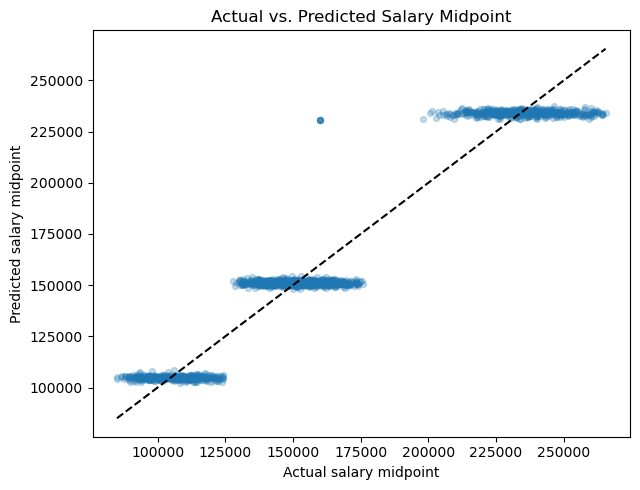

In [26]:
# Compare Ridge predictions with the actual test targets.
plt.figure(figsize=(6.5, 5))
plt.scatter(y_test, ridge_predictions, alpha=0.25, s=18)

# Add the diagonal representing perfect predictions.
ridge_limits = [
    min(y_test.min(), ridge_predictions.min()),
    max(y_test.max(), ridge_predictions.max()),
]
plt.plot(ridge_limits, ridge_limits, '--', color='black')

plt.title('Actual vs. Predicted Salary Midpoint')
plt.xlabel('Actual salary midpoint')
plt.ylabel('Predicted salary midpoint')
plt.tight_layout()
plt.show()

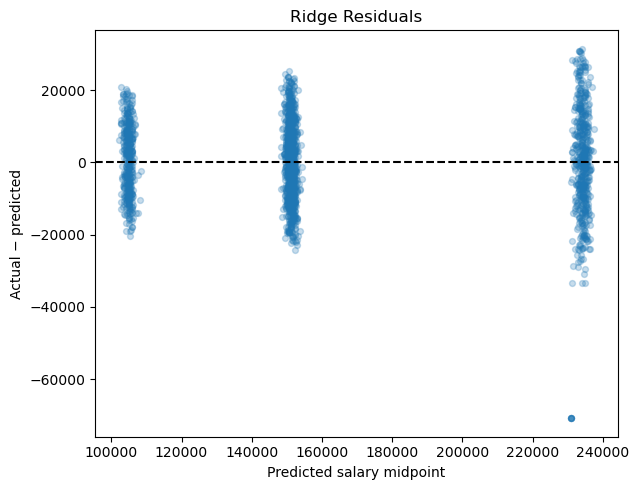

In [27]:
# Calculate and plot Ridge prediction errors.
ridge_residuals = y_test - ridge_predictions

plt.figure(figsize=(6.5, 5))
plt.scatter(ridge_predictions, ridge_residuals, alpha=0.25, s=18)

# Values near the zero line represent small prediction errors.
plt.axhline(0, linestyle='--', color='black')
plt.title('Ridge Residuals')
plt.xlabel('Predicted salary midpoint')
plt.ylabel('Actual − predicted')
plt.tight_layout()
plt.show()

The actual-versus-predicted plot shows how closely predictions follow the ideal diagonal. The residual plot is used to check for systematic overprediction or underprediction; a useful residual pattern should remain centered around zero without a strong curve or widening spread.

For the current saved split, cross validation selected `alpha = 0.001`, indicating that only a small Ridge penalty was needed. Test MAE was approximately **$9,497**, compared with approximately **$40,567** for the mean baseline. Test RMSE was approximately **$12,127**, and R² was approximately **0.938**. Experience-level indicators had the largest standardized coefficients. These results show predictive association within this dataset; the coefficients do not establish that a feature causes salary to change.

### Model 3: Random Forest Regression

#### Modeling decisions

- **Trying a different relationship:** Linear and Ridge Regression add up feature contributions. I wanted to try something different. A decision tree asks a sequence of questions, such as whether a posting is Senior level and then whether it requires a particular skill. This allows the effect of a skill to depend on experience without adding an interaction column myself.
- **Combining many trees:** One detailed tree can memorize the training data. A Random Forest fits trees to different samples of the training rows, sampled with replacement, and averages their salary predictions. Each tree predicts the average training salary in the final group, called a leaf. Averaging helps reduce the instability of a single tree, although a forest can still overfit.
- **Keeping all the features:** I used the same complete feature set as Ridge, including the education and experience indicators. Trees do not estimate linear coefficients, so they do not need the reference categories used for Linear Regression. They also do not need `StandardScaler`: changing a feature's scale preserves the order used to split its values. I kept the existing normalized years feature as it is.
- **Controlling complexity:** Ridge used `alpha` to limit coefficient size. Here, `max_depth` limits how many questions a tree can ask along a path, and `min_samples_leaf` prevents predictions from depending on very small groups. I compared depths of 8 and unlimited (`None`), and leaf sizes of 1 and 5. These are starting choices, not settings I already know are best.
- **Making trees less similar:** I compared `max_features=1.0` (all features considered at each split) with `0.5` (half). Considering fewer features can make the trees less alike, but may also make individual trees less accurate. I fixed `n_estimators=150` to keep this first search manageable; more trees cost more time and do not replace limits on tree complexity.
- **Reusing the evaluation approach:** I used the same five shuffled folds and `random_state=42`, and chose settings by validation MAE. Eight combinations across five folds require 40 forest fits, followed by a refit on all training rows. The trees use squared error to choose splits; MAE is the separate score used to compare forests.
- **Keeping tuning within the training data:** As with Ridge, the parameter search sees only training rows. The test set is used afterward for comparison. Since this notebook compares several models on the same test set, choosing or revising models based on those results would make it part of model selection. A final unbiased check would then need fresh held-out data.

#### Confirming the Random Forest input data

In [28]:
# Reuse the full numeric feature sets loaded at the start of the notebook.
if not X_train.index.equals(y_train.index) or not X_test.index.equals(y_test.index):
    raise ValueError('Feature and target row IDs are not aligned')

if not X_train.columns.equals(X_test.columns):
    raise ValueError('Training and test feature columns do not match')

if X_train.isna().any().any() or y_train.isna().any():
    raise ValueError('Training data contains missing values')

#### Random Forest parameter search

In [29]:
# Parallelize the search, while each individual forest uses one worker.
# This avoids starting parallel work at both levels at once.
forest_estimator = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=1,
)

forest_parameters = {
    'max_depth': [8, None],
    'min_samples_leaf': [1, 5],
    'max_features': [0.5, 1.0],
}

forest_cv = KFold(n_splits=5, shuffle=True, random_state=42)
forest_search = GridSearchCV(
    estimator=forest_estimator,
    param_grid=forest_parameters,
    scoring='neg_mean_absolute_error',
    cv=forest_cv,
    n_jobs=-1,
    return_train_score=True,
)

In [30]:
# GridSearchCV automatically refits the winning settings on all training rows.
forest_search.fit(X_train, y_train)
forest_model = forest_search.best_estimator_
forest_best_index = forest_search.best_index_
forest_cv_mae = -forest_search.best_score_
forest_cv_std = forest_search.cv_results_['std_test_score'][forest_best_index]

print(f'Best settings: {forest_search.best_params_}')
print(f'Mean validation MAE: ${forest_cv_mae:,.0f}')
print(f'Validation MAE standard deviation: ${forest_cv_std:,.0f}')

Best settings: {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 5}
Mean validation MAE: $9,560
Validation MAE standard deviation: $110


#### Checking for overfitting

In [31]:
# Compare errors on each fold's training rows with its validation rows.
# In cv_results_, "test_score" means the validation fold, not X_test.
forest_search_results = pd.DataFrame(forest_search.cv_results_)
forest_validation_results = pd.DataFrame({
    'max_depth': forest_search_results['param_max_depth'],
    'min_samples_leaf': forest_search_results['param_min_samples_leaf'],
    'max_features': forest_search_results['param_max_features'],
    'Training MAE': -forest_search_results['mean_train_score'],
    'Validation MAE': -forest_search_results['mean_test_score'],
    'Validation MAE std': forest_search_results['std_test_score'],
}).sort_values('Validation MAE')

forest_validation_results

,max_depth,min_samples_leaf,max_features,Training MAE,Validation MAE,Validation MAE std
1,8,5,0.5,9258.588069,9559.794231,110.457516
3,8,5,1.0,9215.728234,9581.736162,115.892823
0,8,1,0.5,9073.855168,9585.279503,107.387543
2,8,1,1.0,9027.352691,9605.619907,115.240966
5,None,5,0.5,9130.949134,9636.460886,124.483370
7,None,5,1.0,9064.009350,9691.179940,144.387434
4,None,1,0.5,8097.968016,10087.257029,144.754094
6,None,1,1.0,8102.554776,10099.539874,152.961936


A much smaller training MAE than validation MAE suggests that a model fits its familiar rows better than new ones. I would choose settings using validation MAE, rather than choosing the forest with the smallest training error. This is the same reason Ridge's penalty was worth trying, even if it made the training fit less exact.

The best validation MAE is useful for choosing settings, but it may be optimistic because it won a search over several candidates. Its fold standard deviation describes variation across these splits, not a confidence interval. Random row splits also assume that rows are sufficiently independent; repeated or closely related postings could make these scores look better than performance on genuinely new jobs.

#### Test-set predictions and model comparison

In [32]:
forest_predictions = forest_model.predict(X_test)

# Reuse the baseline, earlier predictions, and regression_metrics helper.
forest_results = pd.DataFrame({
    'Mean baseline': regression_metrics(y_test, baseline_predictions),
    'Linear regression': regression_metrics(y_test, linear_predictions),
    'Ridge regression': regression_metrics(y_test, ridge_predictions),
    'Random forest': regression_metrics(y_test, forest_predictions),
}).T

forest_results

,MAE,RMSE,R²
Mean baseline,40566.999697,48596.955725,-0.001553
Linear regression,9497.197050,12127.472434,0.937627
Ridge regression,9497.197238,12127.472110,0.937627
Random forest,9250.283946,11403.416101,0.944853


Lower MAE and RMSE are better; higher R² is better. Keeping the rows and metrics the same makes this comparison easier to interpret. A more flexible model is not automatically a better one: if Linear and Ridge already describe the relationships well, the forest may add complexity without reducing errors.

#### Interpreting the model

A forest has no single coefficient for a feature. Its built-in importance measures how much splits on each feature reduce squared error during training, averaged across trees and normalized to sum to one. I use this as a first look at what the model relies on.

Unlike the earlier coefficients, these scores do not tell me whether a feature increases or decreases salary, or by how many dollars. They can favor features with many possible split points, such as years of experience, over binary indicators. Related features, such as years and experience level, can share or substitute for each other's importance. The ranking describes this fitted model and does not show that a feature causes salary changes.

In [33]:
forest_importances = pd.Series(
    forest_model.feature_importances_,
    index=X_train.columns,
    name='importance',
).sort_values(ascending=False)

forest_importances.to_frame()

,importance
years_experience_normalized,0.557325
experience_Senior,0.260228
experience_Entry,0.105398
experience_Mid,0.045398
education_phd,0.023714
education_bachelors,0.005080
education_masters,0.000739
skill_pytorch,0.000238
skill_triton_inference_server,0.000202
skill_pandas,0.000177


#### Random Forest diagnostic plots

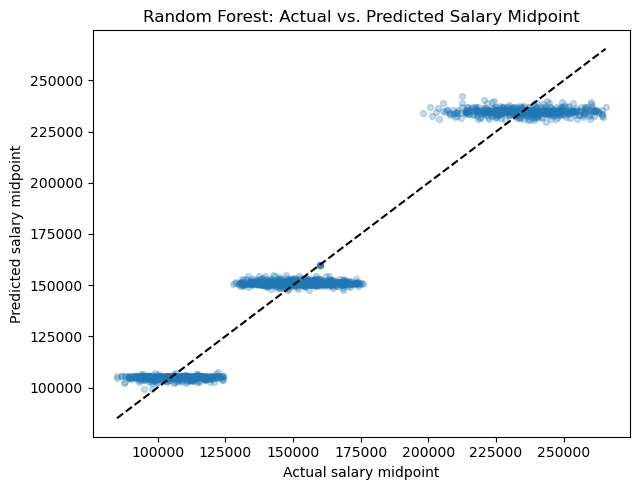

In [34]:
# Use the same actual-versus-predicted plot as the earlier models.
plt.figure(figsize=(6.5, 5))
plt.scatter(y_test, forest_predictions, alpha=0.25, s=18)
forest_limits = [
    min(y_test.min(), forest_predictions.min()),
    max(y_test.max(), forest_predictions.max()),
]
plt.plot(forest_limits, forest_limits, '--', color='black')
plt.title('Random Forest: Actual vs. Predicted Salary Midpoint')
plt.xlabel('Actual salary midpoint')
plt.ylabel('Predicted salary midpoint')
plt.tight_layout()
plt.show()

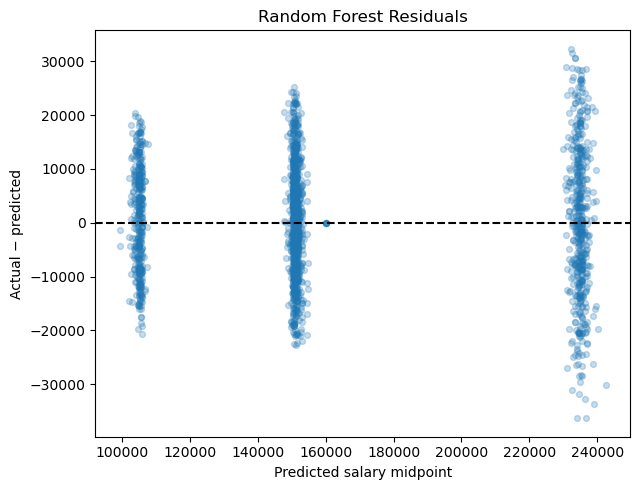

In [35]:
# Positive residuals mean the forest predicted too low.
forest_residuals = y_test - forest_predictions
plt.figure(figsize=(6.5, 5))
plt.scatter(forest_predictions, forest_residuals, alpha=0.25, s=18)
plt.axhline(0, linestyle='--', color='black')
plt.title('Random Forest Residuals')
plt.xlabel('Predicted salary midpoint')
plt.ylabel('Actual − predicted')
plt.tight_layout()
plt.show()

The diagonal and zero-residual line have the same meaning as before. I would look for a remaining curve, widening errors, or consistent underprediction of high salaries. Because this forest averages training salaries, it cannot predict outside the training target range. That can limit its usefulness for jobs with salaries beyond those represented in this dataset.

Parameter definitions and importance caveats: [scikit-learn RandomForestRegressor documentation](https://scikit-learn.org/1.8/modules/generated/sklearn.ensemble.RandomForestRegressor.html).

#### What I learned from this run

For the current saved split, the search selected `max_depth=8`, `min_samples_leaf=5`, and `max_features=0.5`. Its validation MAE was approximately **$9,560**, with a fold-to-fold standard deviation of **$110**. The selected forest's average training-fold MAE was about **$9,259**. In comparison, unrestricted trees with one-row leaves reduced training MAE to about **$8,100** but increased validation MAE to about **$10,100**. This is a useful example of why fitting the training data more closely does not necessarily improve predictions on new rows.

Test MAE was approximately **$9,250**, compared with **$9,497** for both Linear and Ridge Regression and **$40,567** for the mean baseline. The forest reduced test MAE by about **$247**, or **2.6%**, relative to Linear Regression. Test RMSE was approximately **$11,403**, and R² was approximately **0.945**. This is a modest improvement on this split, not enough by itself to establish that the forest will always outperform the simpler models.

Years of experience and the experience-level indicators accounted for most of the built-in importance. That agrees broadly with the earlier models' emphasis on experience, although importance scores and coefficients measure different things. The low skill importance scores do not establish that skills are unimportant in the job market; they describe how this forest used the available features alongside experience and education.

My takeaway is that allowing more flexible relationships helped a little here, while limiting tree complexity helped the model generalize. I would weigh that improvement against the simpler models' easier interpretation, and use training-data validation for any further tuning.